# 03 · Revenue, Growth & Payments

**Business question:** *How is Olist's revenue growing, what drives it, and how do customers pay?*

**New skills today**
- SQL **window functions**: `LAG` (compare to previous row), running totals, moving averages, `RANK`
- **pandas** basics: DataFrames, selecting columns, pivoting
- Making clean, presentation-ready **charts** with matplotlib (saved to `reports/figures/` for the README)

In [1]:
import sys
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../src")                       # so we can import our own chart_style.py
from chart_style import apply_style, money_axis, save, COLORS
apply_style()

con = duckdb.connect(str(Path("..") / "data" / "olist.duckdb"), read_only=True)
def sql(query):
    return con.sql(query).df()

## Definitions (write them down, keep them consistent)
- **Revenue** = item price + freight (`order_revenue`)
- **Valid order** = inside the analysis window (Jan 2017 – Aug 2018) and **not** `canceled` / `unavailable`
- **AOV** (Average Order Value) = revenue ÷ orders

Instead of repeating that filter in every query, we create a **temporary view** called `orders`: a saved query that behaves like a table (it disappears when we close the connection).

In [2]:
con.execute("""
    CREATE OR REPLACE TEMP VIEW orders AS
    SELECT *
    FROM marts.fct_orders
    WHERE in_analysis_window
      AND order_status NOT IN ('canceled', 'unavailable')
""")
print("View 'orders' ready")

View 'orders' ready


## 1. Headline KPIs

In [3]:
kpis = sql("""
    SELECT COUNT(*)                            AS orders,
           ROUND(SUM(order_revenue), 0)        AS revenue,
           COUNT(DISTINCT customer_unique_id)  AS customers,
           ROUND(AVG(order_revenue), 2)        AS aov,
           ROUND(AVG(item_count), 2)           AS items_per_order
    FROM orders
""")
kpis

,orders,revenue,customers,aov,items_per_order
0,97910,15683707.0,94707,160.19,1.14


**pandas tip:** `kpis` is a DataFrame. `kpis["revenue"]` selects a column; `kpis["revenue"][0]` gets the first value.
f-strings (`f"...{value}..."`) put values into text. `:,.0f` means *comma separators, 0 decimals*.

In [4]:
k = kpis.iloc[0]      # first (only) row
print(f"Revenue:   R$ {k['revenue']:,.0f}")
print(f"Orders:    {int(k['orders']):,}")
print(f"Customers: {int(k['customers']):,}")
print(f"AOV:       R$ {k['aov']:,.2f}")

Revenue:   R$ 15,683,707
Orders:    97,910
Customers: 94,707
AOV:       R$ 160.19


## 2. Window functions, the most important SQL skill for analysts
A normal aggregate (`SUM`, `COUNT` with `GROUP BY`) **collapses** rows.
A **window function** calculates across rows **but keeps every row**. Syntax: `FUNCTION() OVER (ORDER BY ...)`

| Function | What it does | Used for |
|---|---|---|
| `LAG(x) OVER (ORDER BY month)` | value of x from the **previous** row | month-over-month growth |
| `SUM(x) OVER (ORDER BY month)` | running total | cumulative revenue |
| `AVG(x) OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)` | moving average | smoothing noisy trends |
| `RANK() OVER (ORDER BY x DESC)` | 1, 2, 3… by x | top-N lists |

In [5]:
monthly = sql("""
    WITH m AS (
        SELECT strftime(order_date, '%Y-%m')  AS month,
               COUNT(*)                        AS orders,
               SUM(order_revenue)              AS revenue
        FROM orders
        GROUP BY month
    )
    SELECT month,
           orders,
           ROUND(revenue, 0)                                              AS revenue,
           ROUND(revenue / orders, 2)                                     AS aov,
           ROUND(LAG(revenue) OVER (ORDER BY month), 0)                   AS prev_month_revenue,
           ROUND(100 * (revenue / LAG(revenue) OVER (ORDER BY month) - 1), 1) AS mom_growth_pct,
           ROUND(SUM(revenue) OVER (ORDER BY month), 0)                   AS cumulative_revenue,
           ROUND(AVG(revenue) OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 0) AS revenue_3m_avg
    FROM m
    ORDER BY month
""")
monthly

,month,orders,revenue,aov,prev_month_revenue,mom_growth_pct,cumulative_revenue,revenue_3m_avg
0,2017-01,787,136943.0,174.01,NaN,NaN,136943.0,136943.0
1,2017-02,1718,283562.0,165.05,136943.0,107.1,420505.0,210253.0
2,2017-03,2617,425618.0,162.64,283562.0,50.1,846123.0,282041.0
3,2017-04,2377,405849.0,170.74,425618.0,-4.6,1251972.0,371676.0
4,2017-05,3640,582711.0,160.09,405849.0,43.6,1834683.0,471392.0
5,2017-06,3205,499652.0,155.90,582711.0,-14.3,2334335.0,496071.0
6,2017-07,3946,578754.0,146.67,499652.0,15.8,2913089.0,553706.0
7,2017-08,4272,661904.0,154.94,578754.0,14.4,3574992.0,580103.0
8,2017-09,4227,717103.0,169.65,661904.0,8.3,4292095.0,652587.0
9,2017-10,4547,764756.0,168.19,717103.0,6.6,5056851.0,714587.0


Read one row, e.g. **2017-11**: `prev_month_revenue` is October's revenue (that's `LAG`), growth is +53% (Black Friday),
and `cumulative_revenue` keeps adding up. The first row's growth is empty (NaN) because January has no previous month.

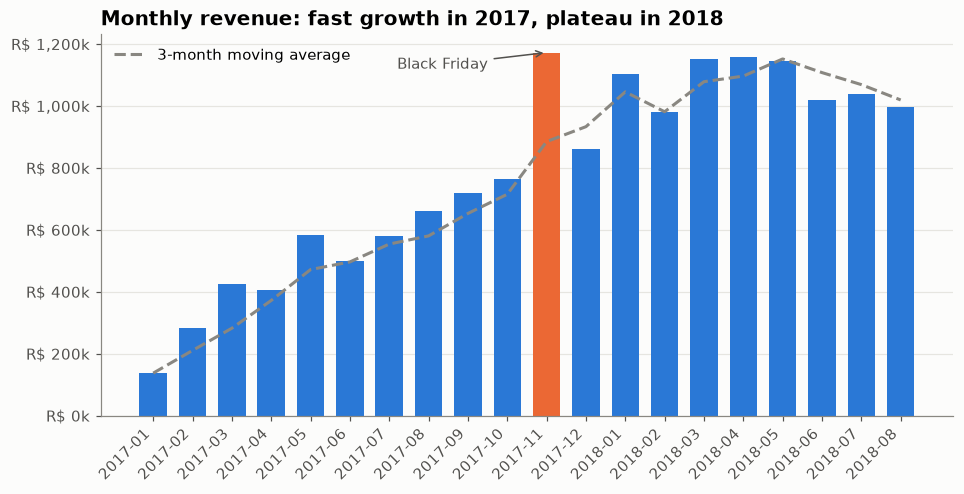

In [6]:
fig, ax = plt.subplots()
bar_colors = [COLORS["orange"] if m == "2017-11" else COLORS["blue"] for m in monthly["month"]]
ax.bar(monthly["month"], monthly["revenue"], color=bar_colors, width=0.7)
ax.plot(monthly["month"], monthly["revenue_3m_avg"], color=COLORS["grey"], linestyle="--", label="3-month moving average")
money_axis(ax, unit="k")
ax.set_title("Monthly revenue: fast growth in 2017, plateau in 2018")
ax.annotate("Black Friday", xy=(10, monthly.loc[10, "revenue"]), xytext=(6.2, 1.12e6),
            arrowprops=dict(arrowstyle="->", color="#52514e"), color="#52514e")
ax.legend(loc="upper left")
plt.xticks(rotation=45, ha="right")
save(fig, "01_monthly_revenue")
plt.show()

**Findings**
- Revenue grew fast through 2017 (roughly R$ 137k → R$ 860k/month by December).
- **Since January 2018 it has plateaued at about R$ 1.0–1.15M per month.** Month-over-month growth hovers around zero.
  Growth has stalled. This is a key business point for leadership.

## 3. Year-over-year: Jan–Aug 2018 vs Jan–Aug 2017

In [7]:
yoy = sql("""
    SELECT YEAR(order_date)          AS year,
           COUNT(*)                  AS orders,
           ROUND(SUM(order_revenue)) AS revenue,
           ROUND(AVG(order_revenue), 2) AS aov
    FROM orders
    WHERE MONTH(order_date) <= 8      -- compare the same months in both years (fair comparison)
    GROUP BY year
    ORDER BY year
""")
yoy["revenue_growth_pct"] = (yoy["revenue"].pct_change() * 100).round(1)   # pandas version of LAG
yoy

,year,orders,revenue,aov,revenue_growth_pct
0,2017,22562,3574992.0,158.45,NaN
1,2018,53531,8593137.0,160.53,140.4


**Finding:** revenue for Jan–Aug grew about **+140% year over year**. Note we compared *the same months*: comparing
all of 2017 to Jan–Aug 2018 would be unfair. `pct_change()` is pandas' shortcut for "compare to previous row".

## 4. Growth driver: more orders, or bigger orders?
Revenue = orders × AOV. Which one grew? Two measures on different scales go in **two separate charts**
(never one chart with two y-axes, which misleads readers).

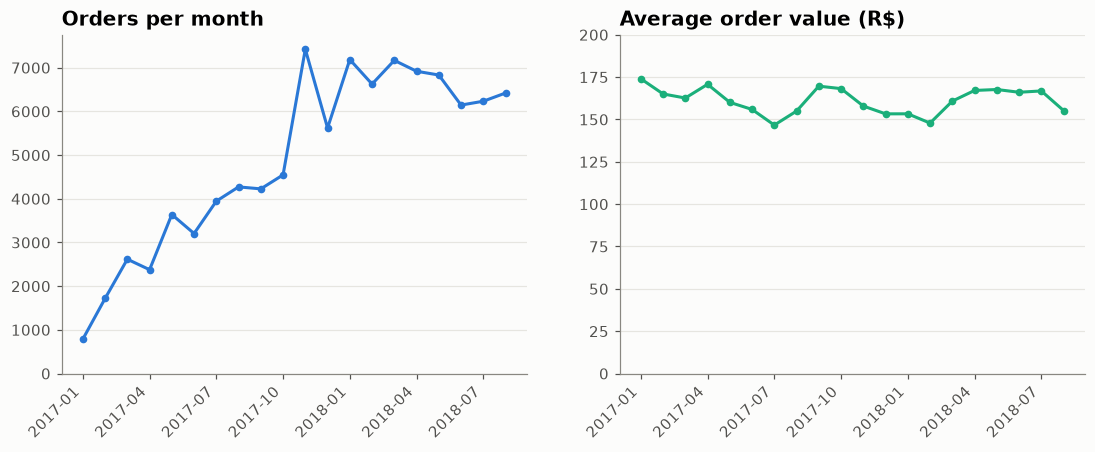

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(monthly["month"], monthly["orders"], color=COLORS["blue"], marker="o", markersize=4)
ax1.set_title("Orders per month")
ax1.set_ylim(0)
ax2.plot(monthly["month"], monthly["aov"], color=COLORS["aqua"], marker="o", markersize=4)
ax2.set_title("Average order value (R$)")
ax2.set_ylim(0, 200)
for ax in (ax1, ax2):
    ax.set_xticks(range(0, len(monthly), 3))
    ax.set_xticklabels(monthly["month"][::3], rotation=45, ha="right")
save(fig, "02_orders_vs_aov")
plt.show()

**Finding:** order volume grew about 8×, while AOV stayed flat around R$ 150–170. **Growth came entirely from acquiring more orders, not from bigger baskets.**
→ Opportunity: raise AOV (bundles, cross-sell, free-shipping thresholds).

## 5. Black Friday 2017

Normal day (Oct 15 – Nov 19): 156 orders
Peak day 2017-11-24: 1,166 orders = 7.5x normal


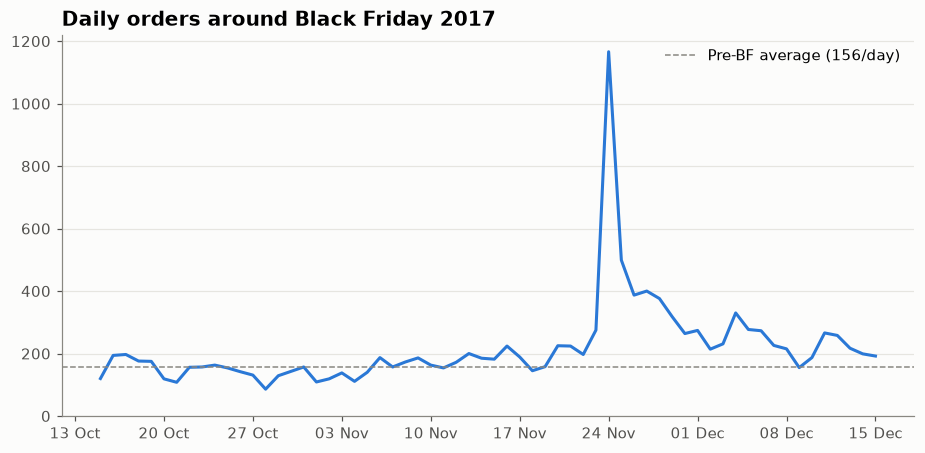

In [9]:
daily = sql("""
    SELECT order_date, COUNT(*) AS orders, ROUND(SUM(order_revenue)) AS revenue
    FROM orders
    WHERE order_date BETWEEN '2017-10-15' AND '2017-12-15'
    GROUP BY order_date
    ORDER BY order_date
""")
baseline = daily[daily["order_date"] < "2017-11-20"]["orders"].mean()    # pandas filtering: df[condition]
peak = daily.loc[daily["orders"].idxmax()]
print(f"Normal day (Oct 15 – Nov 19): {baseline:.0f} orders")
print(f"Peak day {peak['order_date'].date()}: {peak['orders']:,} orders = {peak['orders']/baseline:.1f}x normal")

fig, ax = plt.subplots()
ax.plot(daily["order_date"], daily["orders"], color=COLORS["blue"])
ax.axhline(baseline, color=COLORS["grey"], linestyle="--", linewidth=1, label=f"Pre-BF average ({baseline:.0f}/day)")
ax.set_title("Daily orders around Black Friday 2017")
ax.set_ylim(0)
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.FR))   # one tick per Friday
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend()
save(fig, "03_black_friday")
plt.show()

**Finding:** on Black Friday (24 Nov 2017), orders hit **about 7.5× a normal day**, and demand stayed elevated for about a week after.
→ Logistics and seller capacity need to be planned for this spike, or delivery delays follow (see notebook 05).

## 6. When do customers buy? Weekday × hour heatmap
`pivot()` reshapes a long table (weekday, hour, orders) into a grid, with weekdays as rows and hours as columns. This is a key pandas skill.

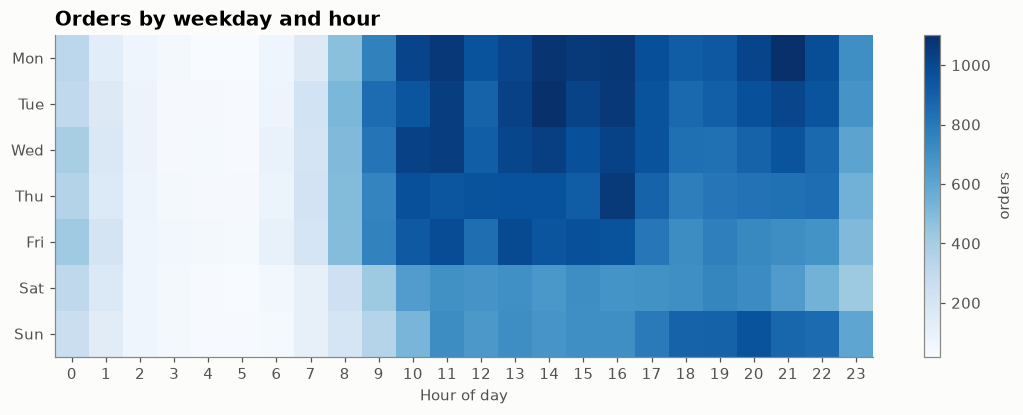

In [10]:
wh = sql("""
    SELECT ISODOW(purchased_at) AS weekday, HOUR(purchased_at) AS hour, COUNT(*) AS orders
    FROM orders
    GROUP BY weekday, hour
""")
grid = wh.pivot(index="weekday", columns="hour", values="orders")
grid.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(grid, cmap="Blues", aspect="auto")      # one hue, light → dark = more orders
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(7));  ax.set_yticklabels(grid.index)
ax.grid(False)
ax.set_xlabel("Hour of day")
ax.set_title("Orders by weekday and hour")
fig.colorbar(im, ax=ax, label="orders")
save(fig, "04_weekday_hour_heatmap")
plt.show()

**Finding:** buying peaks on **weekdays, roughly 10:00–22:00**. Monday–Tuesday are the busiest days and Saturday the quietest, while Sunday picks up in the evening (18:00–22:00). Almost nobody buys 01:00–07:00.
→ Schedule marketing emails/pushes for weekday late mornings; plan site maintenance at night.

## 7. Categories: what sells? (`RANK()` and cumulative share)
Items are the right grain for category analysis → `fct_order_items` joined to `dim_products`.

In [11]:
cats = sql("""
    WITH c AS (
        SELECT p.category,
               SUM(f.item_revenue)                                                   AS revenue,
               SUM(CASE WHEN YEAR(f.order_date) = 2017 AND MONTH(f.order_date) <= 8 THEN f.item_revenue END) AS rev_2017_jan_aug,
               SUM(CASE WHEN YEAR(f.order_date) = 2018 AND MONTH(f.order_date) <= 8 THEN f.item_revenue END) AS rev_2018_jan_aug
        FROM marts.fct_order_items f
        JOIN marts.dim_products p ON f.product_id = p.product_id
        WHERE f.order_date BETWEEN '2017-01-01' AND '2018-08-31'
          AND f.order_status NOT IN ('canceled', 'unavailable')
        GROUP BY p.category
    )
    SELECT RANK() OVER (ORDER BY revenue DESC)                                AS rank,
           category,
           ROUND(revenue)                                                     AS revenue,
           ROUND(100 * revenue / SUM(revenue) OVER (), 1)                     AS share_pct,
           ROUND(100 * SUM(revenue) OVER (ORDER BY revenue DESC) / SUM(revenue) OVER (), 1) AS cumulative_share_pct,
           ROUND(100 * (rev_2018_jan_aug / rev_2017_jan_aug - 1), 0)          AS yoy_growth_pct
    FROM c
    ORDER BY rank
""")
print(f"{len(cats)} categories in total")
cats.head(15)

74 categories in total


,rank,category,revenue,share_pct,cumulative_share_pct,yoy_growth_pct
0,1,health_beauty,1432213.0,9.1,9.1,212.0
1,2,watches_gifts,1294824.0,8.3,17.4,250.0
2,3,bed_bath_table,1239780.0,7.9,25.3,113.0
3,4,sports_leisure,1144754.0,7.3,32.6,133.0
4,5,computers_accessories,1049201.0,6.7,39.3,137.0
5,6,furniture_decor,892438.0,5.7,45.0,111.0
6,7,housewares,770493.0,4.9,49.9,203.0
7,8,cool_stuff,702849.0,4.5,54.4,10.0
8,9,auto,676854.0,4.3,58.7,176.0
9,10,garden_tools,578060.0,3.7,62.4,55.0


The top 18 of 74 categories make up 80% of revenue


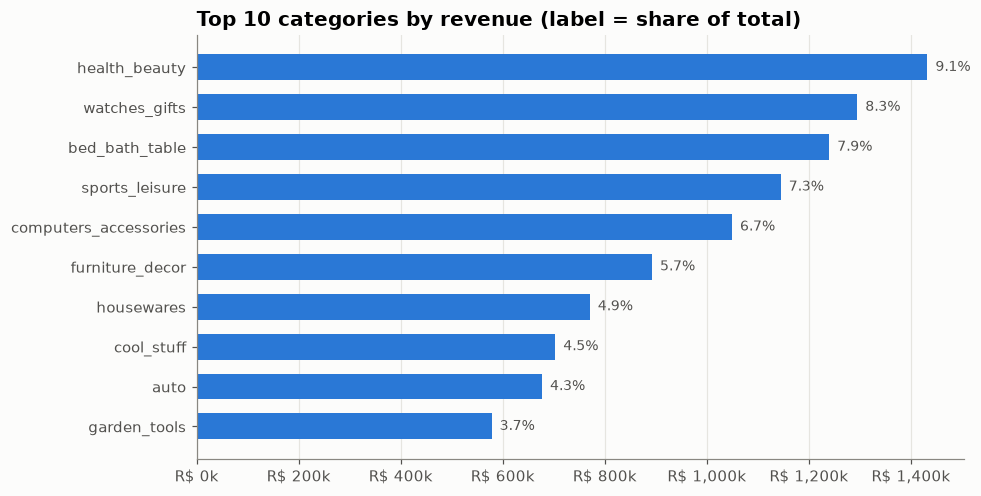

In [12]:
n80 = (cats["cumulative_share_pct"] < 80).sum() + 1
print(f"The top {n80} of {len(cats)} categories make up 80% of revenue")

top10 = cats.head(10).iloc[::-1]          # reverse so the biggest bar is on top
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10["category"], top10["revenue"], color=COLORS["blue"], height=0.65)
for y, (rev, share) in enumerate(zip(top10["revenue"], top10["share_pct"])):
    ax.text(rev, y, f"  {share}%", va="center", color="#52514e", fontsize=9)
money_axis(ax, axis="x", unit="k")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Top 10 categories by revenue (label = share of total)")
save(fig, "05_top_categories")
plt.show()

**Findings:** revenue is spread across many categories. No single category dominates (the #1, health & beauty, is under 10%),
and it takes the top 18 of 74 categories to reach 80%. Look at `yoy_growth_pct` to see which categories are growing fastest.

## 8. Geography: where are the customers?

In [13]:
states = sql("""
    SELECT customer_state                                       AS state,
           COUNT(DISTINCT customer_unique_id)                   AS customers,
           ROUND(SUM(order_revenue))                            AS revenue,
           ROUND(100 * SUM(order_revenue) / SUM(SUM(order_revenue)) OVER (), 1) AS share_pct,
           ROUND(SUM(order_revenue) / COUNT(DISTINCT customer_unique_id), 1)    AS revenue_per_customer
    FROM orders
    GROUP BY state
    ORDER BY revenue DESC
""")
states.head(10)

,state,customers,revenue,share_pct,revenue_per_customer
0,SP,39649,5863233.0,37.4,147.9
1,RJ,12201,2105550.0,13.4,172.6
2,MG,11098,1837646.0,11.7,165.6
3,RS,5213,873635.0,5.6,167.6
4,PR,4806,791702.0,5.0,164.7
5,BA,3240,605913.0,3.9,187.0
6,SC,3493,605523.0,3.9,173.4
7,DF,2052,350127.0,2.2,170.6
8,GO,1927,339390.0,2.2,176.1
9,ES,1946,322014.0,2.1,165.5


**Finding:** São Paulo (SP) alone is **~37% of revenue**, and the top 3 states (SP, RJ, MG) are **~62%**.
Customers in smaller, far-away North and North-East states (e.g. PB, AC, RO, PA) spend *more per customer* (R$ 230–270 vs R$ 148 in SP), partly because freight costs more there.

## 9. Payments: how do customers pay?

In [14]:
pay = sql("""
    SELECT main_payment_type                              AS payment_type,
           COUNT(*)                                       AS orders,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS share_pct,
           ROUND(AVG(order_revenue), 2)                   AS aov,
           ROUND(AVG(installments), 1)                    AS avg_installments
    FROM orders
    WHERE main_payment_type IS NOT NULL
    GROUP BY payment_type
    ORDER BY orders DESC
""")
pay

,payment_type,orders,share_pct,aov,avg_installments
0,credit_card,73891,75.5,166.55,3.6
1,boleto,19479,19.9,144.65,1.0
2,voucher,3028,3.1,114.92,1.1
3,debit_card,1512,1.5,140.33,1.0


,installments,orders,aov
0,1 (paid in full),23675,100.81
1,2-3,22344,135.25
2,4-6,15922,182.08
3,7-24,11950,334.67


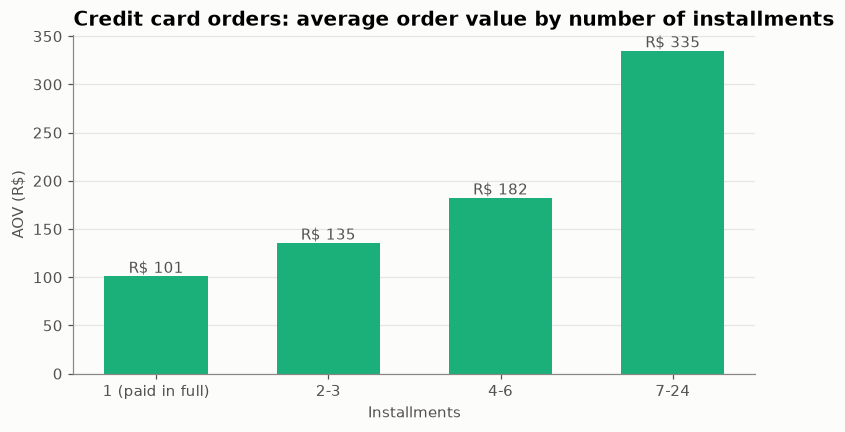

In [15]:
inst = sql("""
    SELECT CASE WHEN installments <= 1 THEN '1 (paid in full)'
                WHEN installments <= 3 THEN '2-3'
                WHEN installments <= 6 THEN '4-6'
                ELSE '7-24' END                AS installments,
           COUNT(*)                            AS orders,
           ROUND(AVG(order_revenue), 2)        AS aov
    FROM orders
    WHERE main_payment_type = 'credit_card'
    GROUP BY 1
    ORDER BY MIN(installments)
""")
display(inst)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(inst["installments"], inst["aov"], color=COLORS["aqua"], width=0.6)
for x, v in enumerate(inst["aov"]):
    ax.text(x, v, f"R$ {v:,.0f}", ha="center", va="bottom", color="#52514e")
ax.set_title("Credit card orders: average order value by number of installments")
ax.set_xlabel("Installments")
ax.set_ylabel("AOV (R$)")
save(fig, "06_installments_aov")
plt.show()

**Findings**
- Credit card pays for **~75% of orders**, boleto (bank slip) ~20%.
- Most card orders are split into installments (avg ~3.6). **Orders paid in 7+ installments have ~3× the AOV** of single payments.
  Installments let customers afford bigger purchases.
→ Promote interest-free installments on high-value categories to lift AOV (connects to finding #4).

---
## Summary: key findings (Revenue & Growth)
| # | Finding | So what? |
|---|---|---|
| 1 | R$ 15.7M revenue from ~98k orders (Jan 2017 – Aug 2018); Jan–Aug revenue **+140% YoY** | Strong growth story |
| 2 | **Revenue plateaued at ~R$ 1.0–1.15M/month throughout 2018** | Acquisition-led growth has stalled; new levers needed |
| 3 | Order volume grew ~8×, **AOV flat at ~R$ 160** | Growth came from volume only → AOV is an untapped lever |
| 4 | **Black Friday = ~7.5× a normal day**, elevated for a week | Plan logistics & seller capacity ahead of peaks |
| 5 | Weekday daytime is peak buying time; Saturday is the quietest day | Time campaigns to weekday late mornings |
| 6 | No category dominates (#1 < 10%); 18 of 74 categories = 80% of revenue | Diversified; low concentration risk |
| 7 | SP ≈ 37% of revenue; SP+RJ+MG ≈ 62% | Heavy dependence on the south-east |
| 8 | Credit card ≈ 75% of orders; 7+ installment orders have ~3× AOV | Installments are a lever for bigger baskets |

Next (notebook 04): **customers**, i.e. cohort retention and RFM segmentation. Why do only 3% come back?

In [16]:
con.close()